In [2]:
import numpy as np
from dataclasses import dataclass, field
import matplotlib.pyplot as plt

SWING = 0
STANCE = 1

R1 = 0
L1 = 1
R2 = 2
L2 = 3

X = 0
Y = 1
Z = 2

In [3]:
# dcm generator parameters
dt = 0.01
m = 5.0
g = 9.81
delta_z = 0.2

# gait parameters
t_sw = 0.5
t_st = 0.5

v_ref_x = 0.2
v_ref_y = 0.0
v_ref_z = 0.0

v_cur_x = 0.2
v_cur_y = 0.0
v_cur_z = 0.0

cur_phases = [STANCE, SWING, SWING, STANCE]
cur_phi = [0.4, 0.4, 0.4, 0.4]
cur_leg_pos = [[0.37,  -0.151, 0.015], 
               [0.32,   0.15,  0.015], 
               [0.04,  -0.1,   0.015],
               [0.046,  0.186, 0.015]]
cur_body_pos = np.array([0.2, 0.014, 0.22])
cur_body_yaw = 0.0

In [4]:
@dataclass
class FootStanceData:
    leg_id: int = 0
    t_start: float = 0.0
    duration: float = 0.1
    pos: list[float] = field(default_factory=lambda: [0.0, 0.0, 0.0])

    def __post_init__(self):
        if len(self.pos) != 3:
            raise ValueError("pos must contain exactly 3 elements")

In [5]:
# 
foot_plan = []
t_rem = t_st
future_phases = cur_phases[:]

# найдем план по времени и фазам для каждой ноги
for i in range(6):
    if i == 0:
        for j in range(4):
            if cur_phases[j] == STANCE:
                t_rem = t_st * (1 - cur_phi[j]) # время до конца текущей фазы опоры
                foot_plan.append(FootStanceData(leg_id=j, t_start=0.0, duration=t_rem, pos=cur_leg_pos[j]))
    else:
        future_phases = [x ^ 1 for x in future_phases] # инвертируем фазы для всех ног
        t_start = (i-1)*t_st + t_rem # находим начальное время для будущих фаз
        for j in range(4):
            if future_phases[j] == STANCE:
                foot_plan.append(FootStanceData(leg_id=j, t_start=t_start, duration=t_st, pos=cur_leg_pos[j]))

# найдем будущие положения ног в фазе опоры
# Ниже компактный Python-аналог FootStepPlanner для ноутбука.
# Он повторяет ту же идею: номинальная точка + ограничение длины ноги + коррекция по heightmap.

def rotz(yaw):
    c, s = np.cos(yaw), np.sin(yaw)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])

def update_footstep_location(p_nom, vision_map):
    # Если карты нет, оставляем номинальную точку без коррекции.
    if vision_map is None:
        return p_nom.copy()

    search_idxs = np.array([
        [ 0,  0], [ 1,  0], [ 1,  1], [ 0,  1], [-1,  1],
        [-1,  0], [-1, -1], [ 0, -1], [ 1, -1], [ 2, -1],
        [ 2,  0], [ 2,  1], [ 2,  2], [ 1,  2], [ 0,  2],
        [-1,  2], [-2,  2], [-2,  1], [-2,  0], [-2, -1],
        [-2, -2], [-1, -2], [ 0, -2], [ 1, -2], [ 2, -2],
    ], dtype=int)

    hm = vision_map['heightmap']
    trav = vision_map['traversability']
    cell = vision_map['cell_size']
    rows, cols = hm.shape

    center_row = int(np.floor((p_nom[Y] - vision_map['origin_y']) / cell)) + rows // 2
    center_col = int(np.floor((p_nom[X] - vision_map['origin_x']) / cell)) + cols // 2

    selected_row, selected_col = center_row, center_col
    found = False
    for dx, dy in search_idxs:
        row = center_row + dy
        col = center_col + dx
        if row < 0 or row >= rows or col < 0 or col >= cols:
            continue
        if trav[row, col] == 0 and np.isfinite(hm[row, col]):
            selected_row, selected_col = row, col
            found = True
            break

    if not found:
        return p_nom.copy()

    # Координаты ячейки пересчитываем обратно в мировую систему координат.
    start_x = vision_map['origin_x'] - 0.5 * cols * cell
    start_y = vision_map['origin_y'] - 0.5 * rows * cell
    p = p_nom.copy()
    p[X] = start_x + (selected_col + 0.5) * cell
    p[Y] = start_y + (selected_row + 0.5) * cell
    p[Z] = hm[selected_row, selected_col] + 0.015
    return p

def predict_footstep(leg_id, body_pos, body_yaw, body_lin_vel, body_lin_vel_cmd,
                     body_yaw_vel_cmd, swing_time_remaining, avg_z_foothold_pos,
                     leg_cfg, vision_map, t_st, k1_fsp, max_leg_length):
    # В ноутбуке считаем только yaw-ориентацию корпуса, этого достаточно для DCM-эксперимента.
    R_body = rotz(body_yaw)
    p0_b = leg_cfg[leg_id]['p0_b']
    hip_anchor_b = leg_cfg[leg_id]['hip_anchor_b']

    twisting_speed_cmd = np.array([0.0, 0.0, body_yaw_vel_cmd])
    yaw_half_step_rot = rotz(-body_yaw_vel_cmd * t_st * 0.5)

    p_cross_omega_cmd = R_body @ np.cross(twisting_speed_cmd, p0_b)
    p_cross_omega_cmd[Z] = 0.0

    dp_hip = np.array(body_lin_vel, dtype=float)
    dp_hip_cmd = np.array(body_lin_vel_cmd, dtype=float) + p_cross_omega_cmd
    dp_hip[Z] = 0.0
    dp_hip_cmd[Z] = 0.0

    k2 = 0.5 * (body_pos[Z] - avg_z_foothold_pos) / g
    velocity_correction = 0.5 * t_st * dp_hip + k1_fsp * (dp_hip - dp_hip_cmd) + k2 * np.cross(dp_hip, twisting_speed_cmd)
    velocity_correction[Z] = 0.0
    velocity_correction[:2] = np.clip(velocity_correction[:2], -0.3, 0.3)

    p_nom = body_pos + R_body @ (yaw_half_step_rot @ p0_b) + np.array(body_lin_vel_cmd) * swing_time_remaining + velocity_correction
    p_nom[Z] = avg_z_foothold_pos

    # Ограничиваем точку по досягаемости относительно физического положения бедра.
    hip_anchor_world = body_pos + R_body @ hip_anchor_b
    p_rel_body = R_body.T @ (p_nom - hip_anchor_world)
    xy_max_sq = max(0.0, max_leg_length ** 2 - p_rel_body[Z] ** 2)
    xy_max = np.sqrt(xy_max_sq)
    xy_norm = np.linalg.norm(p_rel_body[:2])
    if xy_norm > xy_max and xy_norm > 1e-9:
        p_rel_body[:2] *= xy_max / xy_norm
        p_nom = hip_anchor_world + R_body @ p_rel_body
        p_nom[Z] = avg_z_foothold_pos

    return update_footstep_location(p_nom, vision_map)

# Параметры ниже можно переопределить в отдельной ячейке, если в ноутбуке есть реальные данные робота и карты.
# cur_body_pos = np.array(globals().get('cur_body_pos', [0.2, 0.014, 0.205]), dtype=float)
body_yaw0 = cur_body_yaw
body_yaw_vel_cmd = v_ref_z #float(globals().get('body_yaw_vel_cmd', 0.0))
vision_map = globals().get('vision_map', None)
bx = float(globals().get('bx', 0.106))
by = float(globals().get('by', 0.067))
l1 = float(globals().get('l1', 0.0595))
interleave_x = np.array(globals().get('interleave_x', [-0.0038763443526844714, -0.0038763443526844714, 0.0018605967281275296, 0.0018605967281275296]), dtype=float)
interleave_y = np.array(globals().get('interleave_y', [0.1, 0.1, 0.1, 0.1]), dtype=float)
k1_fsp = float(globals().get('k1_fsp', 0.019409446152834336))
max_leg_length = float(globals().get('max_leg_length', 0.3))

# Конфигурация ног совпадает с той, что задается в SwingController.
leg_cfg = {
    R1: {'p0_b': np.array([ bx + l1 + interleave_x[R1], -(by + interleave_y[R1]), 0.0]), 'hip_anchor_b': np.array([ bx + l1, -by, 0.0])},
    L1: {'p0_b': np.array([ bx + l1 + interleave_x[L1],  (by + interleave_y[L1]), 0.0]), 'hip_anchor_b': np.array([ bx + l1,  by, 0.0])},
    R2: {'p0_b': np.array([-(bx + l1 + interleave_x[R2]), -(by + interleave_y[R2]), 0.0]), 'hip_anchor_b': np.array([-(bx + l1), -by, 0.0])},
    L2: {'p0_b': np.array([-(bx + l1 + interleave_x[L2]),  (by + interleave_y[L2]), 0.0]), 'hip_anchor_b': np.array([-(bx + l1),  by, 0.0])},
}

body_lin_vel = np.array([v_cur_x, v_cur_y, 0.0], dtype=float)
body_lin_vel_cmd = np.array([v_ref_x, v_ref_y, 0.0], dtype=float)
pred_pos = {leg: np.array(cur_leg_pos[leg], dtype=float) for leg in range(4)}
pair_seq = [(foot_plan[2 * k].leg_id, foot_plan[2 * k + 1].leg_id) for k in range(len(foot_plan) // 2)]

# Обновляем только pos у уже существующего foot_plan, чтобы остальная логика ноутбука не менялась.
for k, support_pair in enumerate(pair_seq):
    if k == 0:
        continue

    if k == 1:
        # Следующая диагональ уже находится в swing, поэтому используем оставшееся время полета из cur_phi.
        avg_z = np.mean([pred_pos[leg][Z] for leg in pair_seq[0]])
        for leg in support_pair:
            swing_time_remaining = (1.0 - cur_phi[leg]) * t_sw
            pred_pos[leg] = predict_footstep(leg, cur_body_pos, body_yaw0, body_lin_vel, body_lin_vel_cmd,
                                             body_yaw_vel_cmd, swing_time_remaining, avg_z,
                                             leg_cfg, vision_map, t_st, k1_fsp, max_leg_length)
    else:
        # Для более дальних шагов считаем, что корпус движется с командной скоростью,
        # а новая swing-фаза начинается в момент старта предыдущей опорной пары.
        swing_start_t = foot_plan[2 * (k - 1)].t_start
        body_pos_k = cur_body_pos + body_lin_vel_cmd * swing_start_t
        body_yaw_k = body_yaw0 + body_yaw_vel_cmd * swing_start_t
        avg_z = np.mean([pred_pos[leg][Z] for leg in pair_seq[k - 1]])
        for leg in support_pair:
            pred_pos[leg] = predict_footstep(leg, body_pos_k, body_yaw_k, body_lin_vel_cmd, body_lin_vel_cmd,
                                             body_yaw_vel_cmd, t_sw, avg_z,
                                             leg_cfg, vision_map, t_st, k1_fsp, max_leg_length)

    # Перезаписываем только прогнозируемые координаты, а времена и длительности остаются как раньше.
    foot_plan[2 * k].pos = pred_pos[support_pair[0]].tolist()
    foot_plan[2 * k + 1].pos = pred_pos[support_pair[1]].tolist()


In [6]:
foot_plan

[FootStanceData(leg_id=0, t_start=0.0, duration=0.3, pos=[0.37, -0.151, 0.015]),
 FootStanceData(leg_id=3, t_start=0.0, duration=0.3, pos=[0.046, 0.186, 0.015]),
 FootStanceData(leg_id=1, t_start=0.3, duration=0.5, pos=[0.4716236556473155, 0.18100000000000002, 0.015]),
 FootStanceData(leg_id=2, t_start=0.3, duration=0.5, pos=[0.14263940327187252, -0.153, 0.015]),
 FootStanceData(leg_id=0, t_start=0.8, duration=0.5, pos=[0.5716236556473155, -0.153, 0.015]),
 FootStanceData(leg_id=3, t_start=0.8, duration=0.5, pos=[0.2426394032718725, 0.18100000000000002, 0.015]),
 FootStanceData(leg_id=1, t_start=1.3, duration=0.5, pos=[0.6716236556473155, 0.18100000000000002, 0.015]),
 FootStanceData(leg_id=2, t_start=1.3, duration=0.5, pos=[0.34263940327187253, -0.153, 0.015]),
 FootStanceData(leg_id=0, t_start=1.8, duration=0.5, pos=[0.7716236556473156, -0.153, 0.015]),
 FootStanceData(leg_id=3, t_start=1.8, duration=0.5, pos=[0.4426394032718725, 0.18100000000000002, 0.015]),
 FootStanceData(leg_id=1

/tmp/ipykernel_17311/1945826091.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


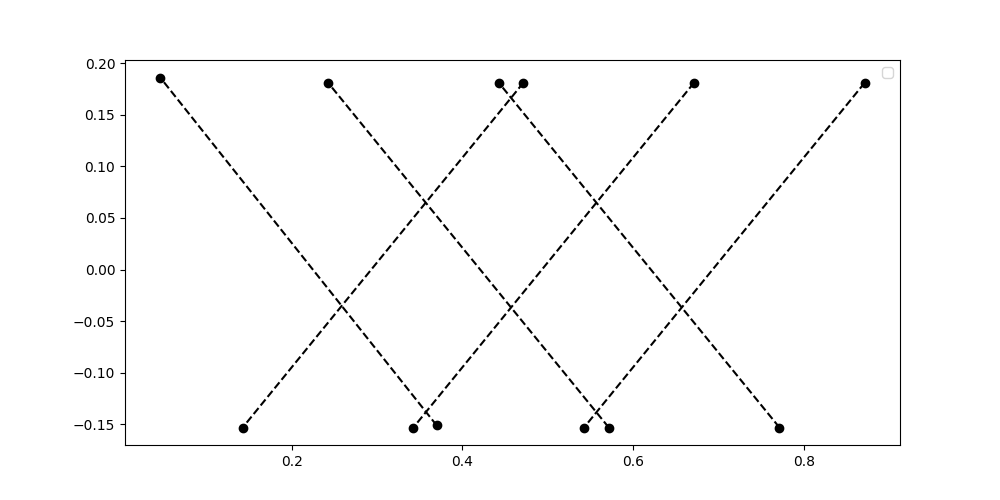

In [7]:
%matplotlib widget
# plot data
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 100
fig, ax = plt.subplots()


for i in range(int(len(foot_plan)/2)): #
    x_lst = [foot_plan[2*i].pos[X], foot_plan[2*i+1].pos[X]]
    y_lst = [foot_plan[2*i].pos[Y], foot_plan[2*i+1].pos[Y]]
    z_lst = [foot_plan[2*i].pos[Z], foot_plan[2*i+1].pos[Z]]
    ax.plot(x_lst, y_lst, 'ko--')


plt.legend()
plt.show()

In [8]:
def segment_intersection(p1, p2, p3, p4):
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    x4, y4 = p4

    D = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)

    if abs(D) < 1e-12:
        return None  # параллельные или совпадающие прямые

    x = ((x1 * y2 - y1 * x2) * (x3 - x4) - (x1 - x2) * (x3 * y4 - y3 * x4)) / D
    y = ((x1 * y2 - y1 * x2) * (y3 - y4) - (y1 - y2) * (x3 * y4 - y3 * x4)) / D

    return (x, y)

def closest_point_on_segment_to_body(body_pos, p1, p2):
    # Ищем ближайшую к телу точку на отрезке в плоскости XY,
    # а Z затем интерполируем вдоль того же отрезка.
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    body_pos = np.asarray(body_pos, dtype=float)

    seg_xy = p2[:2] - p1[:2]
    seg_len_sq = np.dot(seg_xy, seg_xy)

    if seg_len_sq < 1e-12:
        return p1.copy()

    t = np.dot(body_pos[:2] - p1[:2], seg_xy) / seg_len_sq
    t = np.clip(t, 0.0, 1.0)

    closest = p1 + t * (p2 - p1)
    return closest

In [9]:
# определяем r_f
# для этого находим пересечение отрезков текущих ног в STANCE и следующих ног в STANCE

r_f = []

# Первая точка r_f лежит на первом опорном отрезке и выбирается как ближайшая к текущему положению корпуса.
first_support_p1 = foot_plan[0].pos
first_support_p2 = foot_plan[1].pos
r_f.append(closest_point_on_segment_to_body(cur_body_pos, first_support_p1, first_support_p2))

for i in range(int(len(foot_plan)/2-1)):
    p1 = foot_plan[2*i].pos[:2]
    p2 = foot_plan[2*i+1].pos[:2]
    p3 = foot_plan[2*i+2].pos[:2]
    p4 = foot_plan[2*i+3].pos[:2]

    p1_z = foot_plan[2*i].pos[Z]
    p2_z = foot_plan[2*i+1].pos[Z]
    p3_z = foot_plan[2*i+2].pos[Z]
    p4_z = foot_plan[2*i+3].pos[Z]

    intersection = segment_intersection(p1, p2, p3, p4)
    z_intersection = np.mean(np.array([p1_z, p2_z, p3_z, p4_z]))
    if intersection is not None:
        r_f.append(np.array([intersection[0], intersection[1], z_intersection]))
    else:
        raise ValueError("Отрезки не пересекаются, невозможно определить r_f")

In [10]:
# определим r_vrp
r_vrp_d = []
for i in range(len(r_f)):
    r_vrp_d.append(r_f[i] + np.array([0.0, 0.0, delta_z]))

# определим t_step
t_step = [foot_plan[2*i].duration for i in range(int(len(foot_plan)/2-1))]

In [11]:
# найдем DCM для каждой точки r_vrp
omega = np.sqrt(g / delta_z)
dcm_d_eos = [np.array([0.0, 0.0, 0.0]) for _ in range(len(r_vrp_d))]
dcm_d_ini = [np.array([0.0, 0.0, 0.0]) for _ in range(len(r_vrp_d))]

for i in range(len(r_vrp_d)-1, -1, -1):
    if i == len(r_vrp_d)-1:
        dcm_d_eos[i-1] = r_vrp_d[i]
    else:
        dcm_d_eos[i-1] = r_vrp_d[i] + np.exp(-omega * t_step[i]) * (dcm_d_eos[i] - r_vrp_d[i])
        dcm_d_ini[i] = dcm_d_eos[i-1]


In [12]:
# рассчитаем кривые DCM для каждого шага
dcm_d = []

for i in range(len(r_vrp_d)-1):
    t = -t_step[i]
    while (t <= 0):
        dcm_d.append(r_vrp_d[i] + np.exp(omega * t) * (dcm_d_eos[i] - r_vrp_d[i]))
        t += dt

In [ ]:
# рассчитаем x_com

x_com = []
x_com.append(cur_body_pos)

for i in range(len(dcm_d)):
    x_com.append(x_com[i] + dt * omega * (dcm_d[i] - x_com[i]))
    # x_com.append(np.exp(-omega * dt) * x_com[i] + (1 - np.exp(-omega * dt)) * dcm_d[i])
    ## todo: добавить траектории для скорости и ускорения корпуса

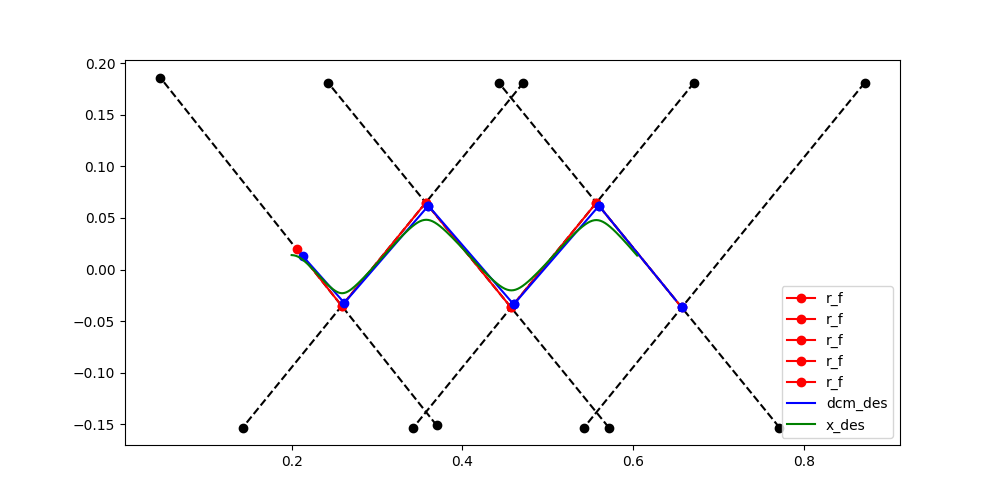

In [14]:
%matplotlib widget
# plot data
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 100
fig, ax = plt.subplots()


for i in range(int(len(foot_plan)/2)):
    x_lst = [foot_plan[2*i].pos[X], foot_plan[2*i+1].pos[X]]
    y_lst = [foot_plan[2*i].pos[Y], foot_plan[2*i+1].pos[Y]]
    z_lst = [foot_plan[2*i].pos[Z], foot_plan[2*i+1].pos[Z]]
    ax.plot(x_lst, y_lst, 'ko--')

for i in range(int(len(r_f)-1)):
    x_lst = [r_f[i][X], r_f[i+1][X]]
    y_lst = [r_f[i][Y], r_f[i+1][Y]]
    z_lst = [r_f[i][Z], r_f[i+1][Z]]
    ax.plot(x_lst, y_lst, 'ro-', label="r_f")

for i in range(len(dcm_d_eos)-1):
    x_lst = [dcm_d_eos[i][X], dcm_d_eos[i+1][X]]
    y_lst = [dcm_d_eos[i][Y], dcm_d_eos[i+1][Y]]
    z_lst = [dcm_d_eos[i][Y], dcm_d_eos[i+1][Z]]
    ax.plot(x_lst, y_lst, 'bo')

x_lst = []
y_lst = []
z_lst = []
for i in range(len(dcm_d)):
    x_lst.append(dcm_d[i][X])
    y_lst.append(dcm_d[i][Y])
    z_lst.append(dcm_d[i][Z])
ax.plot(x_lst, y_lst, 'b-', label="dcm_des")

x_lst = []
y_lst = []
z_lst = []
for i in range(len(x_com)):
    x_lst.append(x_com[i][X])
    y_lst.append(x_com[i][Y])
    z_lst.append(x_com[i][Z])
ax.plot(x_lst, y_lst, 'g-', label="x_des")

plt.legend()
plt.show()


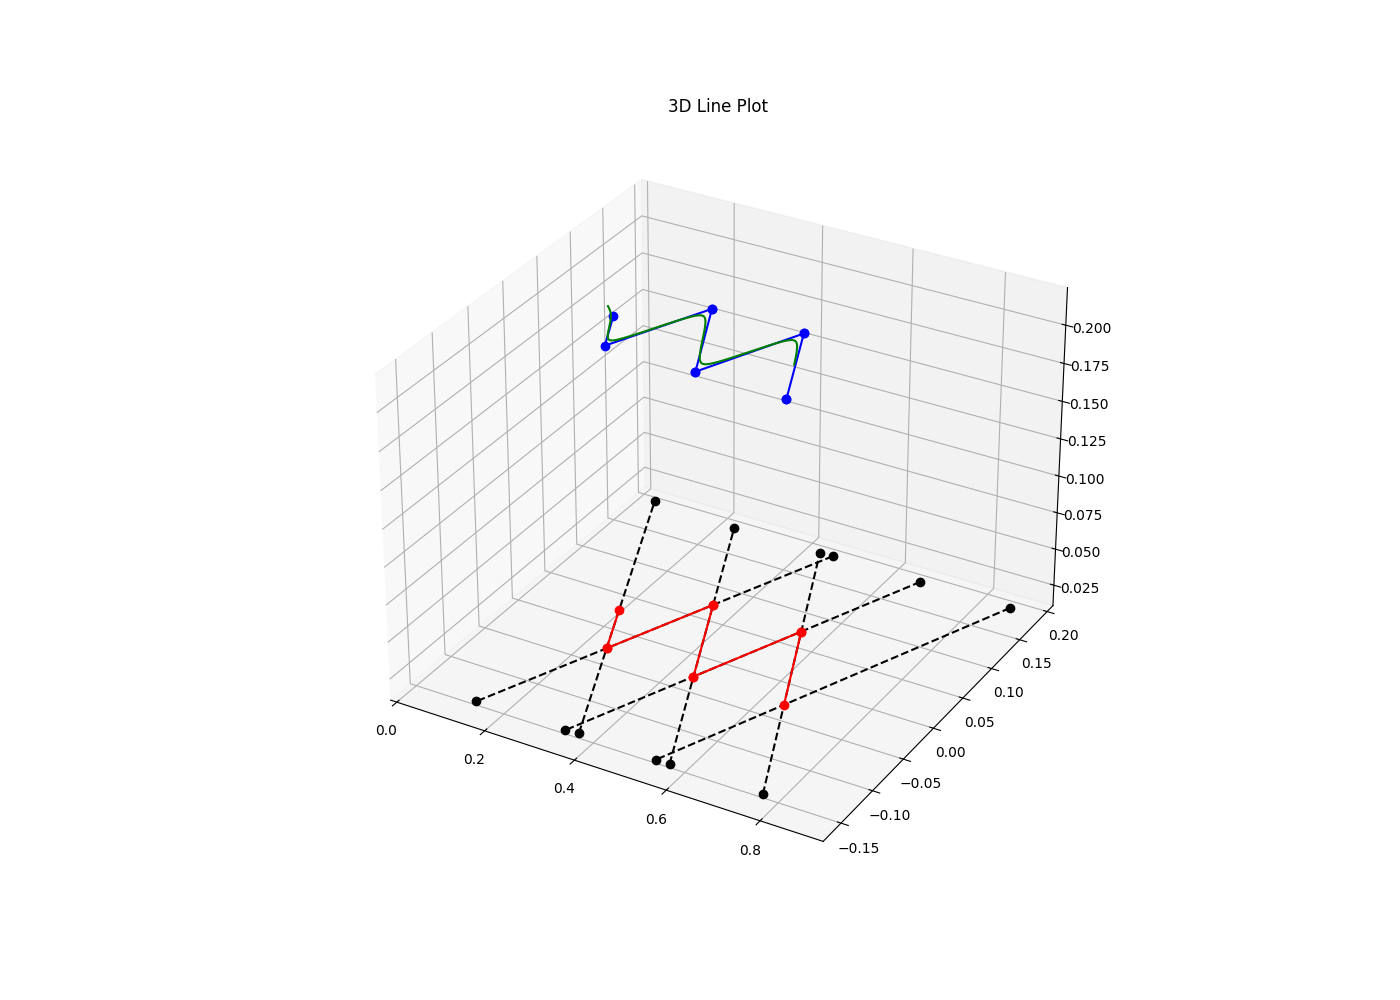

In [15]:

plt.rcParams['figure.figsize'] = [14, 10]
plt.rcParams['figure.dpi'] = 100
from mpl_toolkits import mplot3d

fig = plt.figure()
ax = plt.axes(projection='3d')

for i in range(int(len(foot_plan)/2)):
    x_lst = [foot_plan[2*i].pos[X], foot_plan[2*i+1].pos[X]]
    y_lst = [foot_plan[2*i].pos[Y], foot_plan[2*i+1].pos[Y]]
    z_lst = [foot_plan[2*i].pos[Z], foot_plan[2*i+1].pos[Z]]
    ax.plot3D(x_lst, y_lst, z_lst, 'ko--')

for i in range(int(len(r_f)-1)):
    x_lst = [r_f[i][X], r_f[i+1][X]]
    y_lst = [r_f[i][Y], r_f[i+1][Y]]
    z_lst = [r_f[i][Z], r_f[i+1][Z]]
    ax.plot3D(x_lst, y_lst, z_lst, 'ro-', label="r_f")

for i in range(len(dcm_d_eos)-1):
    x_lst = [dcm_d_eos[i][X], dcm_d_eos[i+1][X]]
    y_lst = [dcm_d_eos[i][Y], dcm_d_eos[i+1][Y]]
    z_lst = [dcm_d_eos[i][Z], dcm_d_eos[i+1][Z]]
    ax.plot3D(x_lst, y_lst, z_lst, 'bo')

x_lst = []
y_lst = []
z_lst = []
for i in range(len(dcm_d)):
    x_lst.append(dcm_d[i][X])
    y_lst.append(dcm_d[i][Y])
    z_lst.append(dcm_d[i][Z])
ax.plot3D(x_lst, y_lst, z_lst, 'b-', label="dcm_des")

x_lst = []
y_lst = []
z_lst = []
for i in range(len(x_com)):
    x_lst.append(x_com[i][X])
    y_lst.append(x_com[i][Y])
    z_lst.append(x_com[i][Z])
# ax.plot(x_lst, y_lst, 'g-', label="x_des")
ax.plot3D(x_lst, y_lst, z_lst, 'green')
ax.set_title('3D Line Plot')
plt.show()